# A look at refractoriness for Hodgkin & Huxley action potentials

Sometimes Hodgkin & Huxley are late for the **action**!

Fire one action potential and the cell will not fire another straight away --
and for a while after that, it will only fire if you push much harder. We
will map both of those out with a two-pulse experiment.

This notebook grades your answers for you, and **each student gets a slightly
different neuron** and their own delay between the two pulses.

## Step 1: Setup

In [ ]:
# Setup inline plotting
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
# For Google Colab, this line installs NEURON
#!pip install neuron quantities

In [ ]:
# Fetch mechanisms
# Uncomment this line if on google colab
#!git clone https://github.com/ABL-Lab/NSC6084-A26.git

In [ ]:
# Compile the mechanisms
# Note: recompiled mechanisms will not take effect until neuron is imported or the jupyter kernel is restarted

# Uncomment this line if on google colab
#!nrnivmodl ./NSC6084-A26/Sept15/mechanisms
# Uncomment this line if running locally
!nrnivmodl mechanisms

In [ ]:
# We will let this library handle unit conversion for us
import quantities as pq
from quantities import um, nS, mV, cm, ms, nA, S, uF, Hz, degrees, s

In [ ]:
# Import and initialize NEURON
import neuron
from neuron import h
h.load_file("stdrun.hoc")

In [ ]:
# Import other modules we need
import numpy as np

## Step 1b: Load your personal exercise parameters

Your soma length sets how much current your cell needs; your delay decides
*where on the refractory curve* the graded questions are asked.

In [ ]:
from obi_notebook import grading

assignment = grading.load()

soma_length = assignment.params["soma_length_um"]
g_leak      = assignment.params["g_leak_nS"]
your_delay  = assignment.params["delay_ms"]   # the questions ask about this delay

print(f"Your soma length:      {soma_length} um")
print(f"Your leak conductance: {g_leak} nS")
print(f"Your test-pulse delay: {your_delay} ms")
print(f"Exercises to submit:   {assignment.exercise_keys}")

## Step 2: Define the circuit
We will use a single compartment, called a "Section" (more on that in next lectures). <br>
It has a cylindrical geometry with length "L" and a diameter "diam", and a specific capacitance "cm" (capacitance per area) <br>
**Unit conversion is a common source of error, so we will be explicit with our units.** 

In [ ]:
soma = h.Section()

### Query NEURON for the expected units for soma.L & soma.diam

In [ ]:
[h.units(x) for x in ["L", "diam"]]

In [ ]:
# soma.L is YOUR personal value, loaded in Step 1b above.
soma.L = soma_length * um
soma.diam =  10 * um

In [ ]:
volume = soma(0.5).volume() * um**3

In [ ]:
area = soma(0.5).area() * um**2

In [ ]:
area

In [ ]:
volume

### Assign the membrane capacitance "everywhere"

In [ ]:
h.units("cm")  # Query the expected units

In [ ]:
specific_membrane_capacitance = 1 * uF/cm**2

In [ ]:
for sec in soma.wholetree():
    sec.cm = specific_membrane_capacitance #  specific membrane capacitance (micro Farads / cm^2)
    sec.Ra = 100

### Add the Hodgkin-Huxley conductances

In [ ]:
# This model includes the transient Na+, persistent K+ and the leak conductances
soma.insert("hh")

That's almost too easy!

### Parametize the leak conductance G = 1/R

In [ ]:
G = g_leak * nS  # R = 1/G in our RC circuit -- YOUR personal value, see Step 1b

# Your G was chosen so that the *specific* leak conductance G/area is the same
# for everyone. It is gl, not G, that decides how excitable the membrane is, so
# this way every cell in the class has the same refractory behaviour per unit
# area -- and the currents you measure still differ, because your soma does.

In [ ]:
v_rest = -70*mV

In [ ]:
tau_m = (specific_membrane_capacitance * area / G).rescale(ms)

In [ ]:
tau_m = soma(0.5).cm / soma(0.5).hh.gl

In [ ]:
# Assign the leak conductance everywhere
for seg in soma:
    seg.hh.gl = (G/area).rescale(S/cm**2)  # Compute specific conductance, and rescale to units of 'S/cm2'
    seg.hh.el = -54.3

In [ ]:
# Read it back off the model, now that gl has actually been assigned.
tau_m = ((soma(0.5).cm * uF/cm**2) / (soma(0.5).hh.gl * S/cm**2)).rescale(ms)
tau_m

### Inspect our parameters

In [ ]:
soma.psection()

In [ ]:
soma.nseg

### Add the conditioning current injection

A brief, strong 1 ms pulse -- enough to fire exactly one action potential.
Scaled to your soma area, so everyone's first spike is the same spike.

In [ ]:
stim = h.IClamp(soma(0.5))

In [ ]:
# 0.15 nA on a 10 um x 10 um soma, scaled to yours as a current *density*.
FIRST_PULSE_NA = 0.15 * (soma_length / 10.0)

stim.delay = 200 * ms   # time to inject current after the start of the simulation
stim.dur = 1 * ms       # stop injecting current at delay+dur
stim.amp = FIRST_PULSE_NA * nA

### Add a second "test" pulse to query refractoriness

In [ ]:
stim2 = h.IClamp(soma(0.5))

In [ ]:
# The largest test pulse we will ever consider, also scaled to your soma.
# A current above this drives a large *passive* voltage deflection, but if
# g_Na stays well below its value during a spike it is not a regenerative
# action potential -- so counting it as one would be wrong.
MAX_TEST_NA = 0.6 * (soma_length / 10.0)

stim2.delay = 205 * ms  # time to inject current after the start of the simulation
stim2.dur = 1 * ms      # stop injecting current at delay+dur
stim2.amp = 0.0 * nA    # amplitude of current to inject

## Step 3: Run the simulation

### Define recordings of simulation variables

In [ ]:
soma_v = h.Vector().record(soma(0.5)._ref_v)
t = h.Vector().record(h._ref_t)

In [ ]:
# Record hh gating variables
hh_vars = ['h', 'm', 'n', 'gna', 'gk']
hh_recordings = {}
for var in hh_vars:
    ref = getattr(soma(0.5).hh, "_ref_"+var )
    hh_recordings[var] = h.Vector().record(ref) 

In [ ]:
hh_recordings

### Run the simulation

In [ ]:
h.finitialize( float(v_rest) )
h.continuerun( float(1000 * ms) )

## Step 4: Plot the results

In [ ]:
plt.plot(t, soma_v, lw=2, label="soma(0.5).v")
plt.legend(fontsize=12)
plt.xlabel("t [ms]", size=16)
plt.ylabel("v [mV]", size=16)
plt.xticks(size=12)
plt.yticks(size=12)
plt.axis([195,220,-80,30])

In [ ]:
plt.plot(t, hh_recordings['m'], lw=2, label="m")
plt.plot(t, hh_recordings['h'], lw=2, label="h")
plt.plot(t, hh_recordings['n'], lw=2, label="n")
plt.legend(fontsize=12)
plt.xlabel("t [ms]", size=16)
plt.ylabel("fraction", size=16)
plt.xticks(size=12)
plt.yticks(size=12)
plt.axis([195,220,0,1])

In [ ]:
plt.plot(t, hh_recordings['gna'], lw=2, label="gna")
plt.plot(t, hh_recordings['gk'], lw=2, label="gk")
plt.legend(fontsize=12)
plt.xlabel("t [ms]", size=16)
plt.ylabel("fraction", size=16)
plt.xticks(size=12)
plt.yticks(size=12)
plt.axis([195,220,0, 0.05])

### Why there is a refractory period at all

Look at the `h` trace above. During the action potential the sodium
inactivation gate slams shut, and it takes **milliseconds** to reopen. Until
it does, most of the sodium channels are simply unavailable, no matter what
you do to the voltage -- and `n` is still elevated, so the K+ conductance is
still pulling the cell down. That is the whole story of what follows.

In [ ]:
def find_spikes(v, t):
    """ Returns times of spikes for a voltage trace and time grid"""
    
    # look for upward crossing of 0mV
    v_arr = np.array(v)
    t_arr = np.array(t) 
    # This is tricky & powerful notation! Let's discuss in class!
    return t_arr[1:][(v_arr[1:]>0) & (v_arr[:-1]<0)] 

In [ ]:
spike_times = find_spikes(soma_v, t)

In [ ]:
spike_times, len(spike_times)

In [ ]:
plt.plot(t, soma_v, lw=2, label="soma(0.5).v")
plt.plot(spike_times, len(spike_times)*[0], 'r.')
plt.legend(fontsize=12)
plt.xlabel("t [ms]", size=16)
plt.ylabel("v [mV]", size=16)
plt.xticks(size=12)
plt.yticks(size=12)
plt.axis([200,250,-80,30])

### Did the *second* pulse fire a spike?

This is the one measurement everything else is built on, and it has a trap in
it. The obvious test -- "is there a spike after the second pulse?" -- is
wrong at short delays, because the conditioning action potential is still
rising when the second pulse lands, and gets counted as the second pulse's
own spike. That makes the absolute refractory period come out as zero.

Counting spikes over the **whole trace** avoids it: the conditioning pulse on
its own always gives exactly one, so two means the test pulse added one. Two
pulses that merge into a single broad action potential still count as one,
which is the answer we want.

In [ ]:
def count_spikes(stim_amp, delay):
    """ Spikes in the whole trace, with the test pulse at 200+delay ms. """
    stim2.amp = stim_amp   # nA
    stim2.delay = 200 + delay
    h.finitialize( float(v_rest) )
    h.continuerun( float(400 * ms) )
    return len(find_spikes(soma_v, t))

def is_second_pulse_causing_spike(stim_amp, delay):
    """ +1 if the test pulse fired a spike of its own, -1 otherwise.

    Signed rather than boolean so scipy.optimize.bisect can find the crossing.
    """
    return 1 if count_spikes(stim_amp, delay) >= 2 else -1

In [ ]:
# Sanity check: the conditioning pulse alone must fire exactly one spike.
count_spikes(0.0, 10)

### Using this function, now we can search for the rheobase
at a particular delay. Example: delay = 10 ms. We will consider currents up to
`MAX_TEST_NA`, because anything bigger than that is driving the membrane close
to 0.0 mV even without spiking (as we saw above).

In [ ]:
stim_amp = np.linspace(0, MAX_TEST_NA, 60)
is_spiking = [is_second_pulse_causing_spike(x, delay = 10) for x in stim_amp]

In [ ]:
plt.plot(stim_amp, is_spiking, lw=2)
plt.xlabel("stim_amp [nA]", size=16)
plt.ylabel("is_spiking [a.u.]", size=16)
plt.xticks(size=12)
plt.yticks(size=12)

### Now let's search for the zero-crossing of this function for each delay

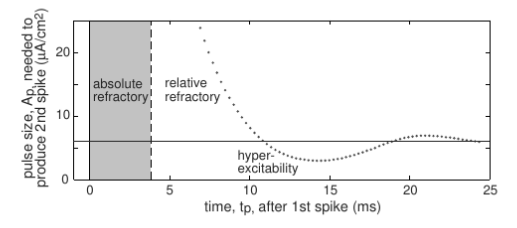

To see if we can reproduce this figure from Izhikevich, 2006

### Binary search will do the trick to find the zero-crossing
... and scipy.optimize.bisect is can do this for us.  

In [ ]:
import scipy.optimize

In [ ]:
def find_second_pulse_rheobase(delay, xtol=1e-4):
    """ Smallest test pulse (nA) that fires a spike of its own at this delay.

    Returns -1 in the absolute refractory region, where even MAX_TEST_NA does
    nothing -- a negative rheobase is not a real current, so it is easy to spot.
    """
    if is_second_pulse_causing_spike(MAX_TEST_NA, delay) < 0:
        return -1.0
    return scipy.optimize.bisect(
        is_second_pulse_causing_spike, 0.0, MAX_TEST_NA,
        args=(delay,), xtol=xtol, maxiter=60,
    )

In [ ]:
find_second_pulse_rheobase(10.0123)

In [ ]:
find_second_pulse_rheobase(4)

### Map out the whole refractory curve

Now sweep the delay. Below some delay nothing works at all -- the **absolute
refractory period**. Above it the cell will fire, but needs more current than
usual, and that excess decays away over tens of ms -- the **relative
refractory period**.

In [ ]:
delay = np.array([1,2,4,5,6,7,8,10,12,14,16,18,20,25,30,40,60])
rheobase = np.array([find_second_pulse_rheobase(x) for x in delay])
rheobase

In [ ]:
# First delay at which a spike is possible at all
idx_relative_ref = np.searchsorted(rheobase > 0, True)
abs_refractory_period = delay[idx_relative_ref]
abs_refractory_period

In [ ]:
plt.plot(delay[idx_relative_ref:], rheobase[idx_relative_ref:], lw=2,
         label="relative refractory")
plt.fill_between([0, abs_refractory_period], 1.1*rheobase.max(), -0.1,
                 color="C1", alpha=0.3, label="absolute refractory")
plt.axvline(your_delay, color='C2', ls='--', label='your delay')
plt.xlabel("delay [ms]", size=16)
plt.ylabel("rheobase [nA]", size=16)
plt.legend(fontsize=12)
plt.axis([0, 60, -0.1, 1.1*rheobase.max()])

Compare the shape with the classic figure from Izhikevich (2006) -- and look
carefully at the far right of your curve. Somewhere around 25-30 ms the
rheobase dips **below** its resting value: for a brief window the cell is
*easier* to fire than it was before the first spike. That is the
**supernormal** (superexcitable) period, and it comes from the slow
after-depolarisation left behind by the action potential.

---

## Now it's your turn! Questions with answer feedback

Answer each question for **your** neuron, using the parameters printed in
Step 1b. Each `submit` call grades one answer and leaves a record in StudiUM;
you can re-run a cell to resubmit a better answer.

Answers are scored on relative error: within 5% earns full credit, fading to
zero at 20% off.

### Question 1 -- The rheobase at your own delay

Find the smallest test pulse that fires a spike of its own when it arrives
`your_delay` ms after the conditioning spike. Report it in **nA**.

Use a tight tolerance -- the curve is steep at short delays, and reading the
value off the sweep above is not accurate enough.

In [ ]:
rheobase_at_delay = None # Fill in 

print(f"At {your_delay} ms the cell needs {rheobase_at_delay:.5g} nA")
assignment.submit(rheobase_at_delay, "rheobase_at_delay")

### Question 2 -- How much harder is that than usual?

Now measure the rheobase of a **lone** 1 ms pulse -- no conditioning spike at
all -- and report how many times larger the Question 1 answer is. It is a
ratio, so no units.

Notice what this number does *not* depend on: your soma area cancels, so it is
a property of the membrane rather than of your particular cell. Everyone with
the same delay gets the same answer, and it is the honest measure of how
refractory the cell still is.

> To measure a lone pulse, switch the conditioning pulse off with
> `stim.amp = 0`, and remember that "fired" now means **one** spike in the
> trace rather than two. Put `stim.amp` back afterwards.

In [ ]:
isolated_rheobase = None # Fill in
refractory_factor = rheobase_at_delay / isolated_rheobase

print(f"A rested cell needs {isolated_rheobase:.5g} nA; at {your_delay} ms it needs "
      f"{refractory_factor:.3f} times that")
assignment.submit(refractory_factor, "refractory_factor")

---

### **Bonus**

Near to rheobase, the *latency* of the action potential depends strongly on the stimulus current. Plot the action potential voltage trajectory for
different stimulus currents slightly above rheobase to show this dependence.


In [ ]:
stim2.amp = 0.0 * nA        # only the first pulse for this one
stim.dur = 1 * ms

# assume isolated_rheobase from previous question
print(f"lone-pulse rheobase: {isolated_rheobase:.6g} nA")

In [ ]:
for factor in [1.0001, 1.001, 1.01, 1.05, 1.2, 1.5]:
    stim.amp = factor * isolated_rheobase
    h.finitialize( float(v_rest) )
    h.continuerun( float(400 * ms) )
    plt.plot(t, soma_v, lw=2, label="%.4f x rheobase" % factor)
stim.amp = FIRST_PULSE_NA * nA
plt.legend(fontsize=10)
plt.xlabel("t [ms]", size=16)
plt.ylabel("v [mV]", size=16)
plt.axis([198, 230, -80, 50])